# 04 - Baseline Models

## Objectives
- Train and evaluate multiple baseline classification models
- Establish performance benchmarks
- Compare models for dropout prediction
- **Verify failed_units features fix coefficient anomalies**
- Select best model for optimization

**Models**: Logistic Regression, Decision Tree, Random Forest, XGBoost, KNN

**Metrics**: Accuracy, Precision, Recall, F1-Score, ROC-AUC

## 4.1 Setup and Imports

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import time
import joblib
from pathlib import Path
from typing import Dict, Tuple, Any

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, learning_curve
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

In [86]:
sys.path.append('..')

In [87]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 4.2 Load Processed Data

In [88]:
data_dir = Path('../data/processed')

try:
    X_train = pd.read_csv(data_dir / 'X_train_full.csv')
    y_train = pd.read_csv(data_dir / 'y_train_full.csv').values.ravel()
    X_val = pd.read_csv(data_dir / 'X_val_full.csv')
    y_val = pd.read_csv(data_dir / 'y_val_full.csv').values.ravel()
    X_test = pd.read_csv(data_dir / 'X_test_full.csv')
    y_test = pd.read_csv(data_dir / 'y_test_full.csv').values.ravel()
    
    print(f"- Full model data loaded")
    print(f"    Train: {X_train.shape}")
    print(f"    Val:   {X_val.shape}")
    print(f"    Test:  {X_test.shape}")
except FileNotFoundError:
    print("- Processed data not found. Loading from engineered dataframe...")
    df = pd.read_pickle(data_dir / 'df_engineered.pkl')
    
    from sklearn.model_selection import train_test_split
    exclude_cols = ['Target', 'Target_encoded', 'Dropout_numeric']
    feature_cols = [c for c in df.columns if c not in exclude_cols and df[c].dtype in ['int64', 'float64']]
    
    X = df[feature_cols]
    y = df['Target_encoded'] if 'Target_encoded' in df.columns else (df['Target'] == 'Dropout').astype(int)
    
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
    print(f"- Data loaded and split from engineered dataframe")
print()

print(f"Class Distribution:")
for name, y_set in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dropout_pct = y_set.mean() * 100
    print(f"    {name}: {dropout_pct:.1f}% dropout ({y_set.sum():.0f}/{len(y_set)})")
print()

print(f"Total features: {X_train.shape[1]}")

# Check for failed_units features
failed_features = [c for c in X_train.columns if 'failed_units' in c.lower()]
if failed_features:
    print(f"+ failed_units features found: {failed_features}")
else:
    print("- No failed_units features detected - coefficients may show anomalies")

- Full model data loaded
    Train: (2178, 51)
    Val:   (726, 51)
    Test:  (726, 51)

Class Distribution:
    Train: 39.2% dropout (853/2178)
    Val: 39.1% dropout (284/726)
    Test: 39.1% dropout (284/726)

Total features: 51
+ failed_units features found: ['failed_units_sem1', 'failed_units_sem2', 'failed_units_total']


## 4.3 Helper Functions

In [89]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model") -> Dict[str, Any]:
    """Train and evaluate a classification model."""
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    start_time = time.time()
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    predict_time = time.time() - start_time

    results = {
        'model': model,
        'model_name': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'train_time': train_time,
        'predict_time': predict_time,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    results['cv_mean'] = cv_scores.mean()
    results['cv_std'] = cv_scores.std()

    return results

In [90]:
def print_model_results(results):
    """Print formatted model evaluation results."""
    print(f"{'='*60}")
    print(f"{results['model_name']}")
    print(f"{'='*60}")
    print(f"    Accuracy:   {results['accuracy']:.4f}")
    print(f"    Precision:  {results['precision']:.4f}")
    print(f"    Recall:     {results['recall']:.4f}")
    print(f"    F1-Score:   {results['f1_score']:.4f}")
    print(f"    ROC-AUC:    {results['roc_auc']:.4f}")
    print(f"    CV ROC-AUC: {results['cv_mean']:.4f} (±{results['cv_std']:.4f})")
    print(f"    Train Time: {results['train_time']:.3f}s")

In [91]:
def plot_confusion_matrices(results_list, figsize=(18, 5)):
    """Plot confusion matrices for multiple models side by side."""
    n_models = len(results_list)
    fig, axes = plt.subplots(1, n_models, figsize=(float(figsize[0]), float(figsize[1])))
    if n_models == 1:
        axes = [axes]
    for i, results in enumerate(results_list):
        ax = axes[i]
        cm = results['confusion_matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Graduate', 'Dropout'],
                    yticklabels=['Graduate', 'Dropout'], cbar=False)
        ax.set_title(results['model_name'], fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    plt.suptitle('Confusion Matrices Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [92]:
def plot_roc_curves(results_list, y_test, figsize=(10, 8)):
    """Plot ROC curves for multiple models."""
    fig, ax = plt.subplots(figsize=(float(figsize[0]), float(figsize[1])))
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    for i, results in enumerate(results_list):
        fpr, tpr, _ = roc_curve(y_test, results['y_proba'])
        auc = results['roc_auc']
        ax.plot(fpr, tpr, color=colors[i % len(colors)], linewidth=2.5,
                label=f"{results['model_name']} (AUC = {auc:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random Classifier')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('../reports/figures/roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

In [93]:
def plot_metrics_comparison(results_list, figsize=(14, 6)):
    """Plot bar chart comparing all metrics across models."""
    metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
    fig, ax = plt.subplots(figsize=(float(figsize[0]), float(figsize[1])))
    x = np.arange(len(metrics))
    width = 0.8 / len(results_list)
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    for i, results in enumerate(results_list):
        values = [results[m] for m in metrics]
        offset = (i - len(results_list)/2 + 0.5) * width
        ax.bar(x + offset, values, width, label=results['model_name'],
               color=colors[i % len(colors)], alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', '\n').title() for m in metrics], fontsize=10)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../reports/figures/metrics_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4.4 Model 1: Logistic Regression (Interpretable Baseline)

In [94]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(
    penalty='l2', C=1.0, solver='liblinear',
    class_weight='balanced', max_iter=1000, random_state=42
)

lr_results = evaluate_model(
    lr_model, X_train_scaled, y_train, X_test_scaled, y_test,
    model_name="Logistic Regression"
)
print_model_results(lr_results)

Logistic Regression
    Accuracy:   0.9201
    Precision:  0.8693
    Recall:     0.9366
    F1-Score:   0.9017
    ROC-AUC:    0.9749
    CV ROC-AUC: 0.9484 (±0.0099)
    Train Time: 0.063s


In [95]:
# Display coefficients and VERIFY failed_units fix
if hasattr(lr_results['model'], 'coef_'):
    feature_names = X_train.columns
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': lr_results['model'].coef_[0]
    }).sort_values('Coefficient', ascending=False)
    
    print("Top 10 Dropout Risk Factors (Positive Coefficients):")
    print("-" * 60)
    for _, row in coef_df.head(10).iterrows():
        marker = '[NEW]' if 'failed_units' in row['Feature'].lower() else '  '
        print(f"{marker} {row['Feature']:<45s} | {row['Coefficient']:+.4f}")
    print()
    
    print("Top 10 Dropout Protective Factors (Negative Coefficients):")
    print("-" * 60)
    for _, row in coef_df.tail(10).iterrows():
        marker = '[NEW]' if 'failed_units' in row['Feature'].lower() else '  '
        print(f"{marker} {row['Feature']:<45s} | {row['Coefficient']:+.4f}")
    print()
    
    # VERIFICATION: Check if failed_units features are risk factors (positive)
    print("=" * 60)
    print("FAILED_UNITS VERIFICATION")
    print("=" * 60)
    failed_coeffs = coef_df[coef_df['Feature'].str.contains('failed_units', case=False)]
    if len(failed_coeffs) > 0:
        for _, row in failed_coeffs.iterrows():
            status = "+ CORRECT (risk factor)" if row['Coefficient'] > 0 else "- UNEXPECTED"
            print(f"    {row['Feature']:<40s} = {row['Coefficient']:+.4f} → {status}")
        print()

        # Check if 'enrolled' is still a risk factor (it should be less so now)
        enrolled_coeffs = coef_df[coef_df['Feature'].str.contains('enrolled', case=False)]
        print(f"'Enrolled' coefficients after fix:")
        for _, row in enrolled_coeffs.iterrows():
            print(f"    {row['Feature']:<40s} = {row['Coefficient']:+.4f}")
    else:
        print("!!! No failed_units features found! Running old feature set.")
        print("    Expected: failed_units_sem1, failed_units_sem2, failed_units_total")
        print("    'Enrolled' may still appear as a risk factor (multicollinearity artifact)")

Top 10 Dropout Risk Factors (Positive Coefficients):
------------------------------------------------------------
[NEW] failed_units_sem1                             | +0.8233
[NEW] failed_units_total                            | +0.7572
   evaluation_intensity_sem1                     | +0.7258
[NEW] failed_units_sem2                             | +0.6479
   Curricular units 1st sem (credited)           | +0.5653
   Course                                        | +0.4836
   disengagement_sem1                            | +0.4738
   financial_stress                              | +0.4486
   International                                 | +0.4108
   perfect_sem1                                  | +0.3901

Top 10 Dropout Protective Factors (Negative Coefficients):
------------------------------------------------------------
   Curricular units 2nd sem (without evaluations) | -0.1900
   grade_per_approved_unit_sem1                  | -0.2260
   Curricular units 1st sem (approved)         

## 4.5 Model 2: Decision Tree (Rule-Based)

In [96]:
dt_model = DecisionTreeClassifier(
    criterion='gini', max_depth=10, min_samples_split=20,
    min_samples_leaf=10, class_weight='balanced', random_state=42
)

dt_results = evaluate_model(
    dt_model, X_train, y_train, X_test, y_test,
    model_name="Decision Tree"
)
print_model_results(dt_results)

print()
print(f"Tree Properties:")
print(f"    Depth: {dt_results['model'].get_depth()}")
print(f"    Leaves: {dt_results['model'].get_n_leaves()}")

Decision Tree
    Accuracy:   0.8884
    Precision:  0.8306
    Recall:     0.8979
    F1-Score:   0.8629
    ROC-AUC:    0.9631
    CV ROC-AUC: 0.9085 (±0.0139)
    Train Time: 0.033s

Tree Properties:
    Depth: 10
    Leaves: 57


## 4.6 Model 3: Random Forest (Ensemble)

In [97]:
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, class_weight='balanced', n_jobs=-1, random_state=42
)

rf_results = evaluate_model(
    rf_model, X_train, y_train, X_test, y_test,
    model_name="Random Forest"
)
print_model_results(rf_results)

Random Forest
    Accuracy:   0.9174
    Precision:  0.8758
    Recall:     0.9190
    F1-Score:   0.8969
    ROC-AUC:    0.9723
    CV ROC-AUC: 0.9481 (±0.0104)
    Train Time: 0.563s


In [98]:
# Feature importance
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_results['model'].feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 15 Features (Random Forest):")
print("-" * 55)
for i, (_, row) in enumerate(rf_importance.head(15).iterrows(), 1):
    bar = '█' * int(row['Importance'] * 100)
    marker = '[FIX]' if 'failed_units' in row['Feature'].lower() else \
             ('[NEW]' if row['Feature'] in ['approval_rate_sem1', 'approval_rate_sem2',
              'grade_momentum', 'grade_decline', 'financial_stress', 'perfect_sem1',
              'disengagement_sem1', 'parent_education', 'evaluation_intensity_sem1',
              'credit_utilization_sem1', 'total_course_load', 'grade_per_approved_unit_sem1']
              else '     ')
    print(f"{marker} {i:2d}. {row['Feature']:<38s} | {row['Importance']:.4f} {bar}")


Top 15 Features (Random Forest):
-------------------------------------------------------
[NEW]  1. approval_rate_sem2                     | 0.1568 ███████████████
[FIX]  2. failed_units_total                     | 0.1359 █████████████
[FIX]  3. failed_units_sem2                      | 0.1002 ██████████
       4. Curricular units 2nd sem (approved)    | 0.0973 █████████
[NEW]  5. approval_rate_sem1                     | 0.0680 ██████
[FIX]  6. failed_units_sem1                      | 0.0585 █████
       7. Curricular units 2nd sem (grade)       | 0.0448 ████
       8. Curricular units 1st sem (approved)    | 0.0350 ███
[NEW]  9. perfect_sem1                           | 0.0284 ██
      10. Curricular units 1st sem (grade)       | 0.0267 ██
[NEW] 11. financial_stress                       | 0.0227 ██
[NEW] 12. grade_momentum                         | 0.0214 ██
[NEW] 13. grade_per_approved_unit_sem1           | 0.0203 ██
      14. Tuition fees up to date                | 0.0142 █
[NEW] 15

## 4.7 Model 4: XGBoost (Gradient Boosting)

In [99]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

xgb_results = evaluate_model(
    xgb_model, X_train, y_train, X_test, y_test,
    model_name="XGBoost"
)
print_model_results(xgb_results)

XGBoost
    Accuracy:   0.9298
    Precision:  0.9003
    Recall:     0.9225
    F1-Score:   0.9113
    ROC-AUC:    0.9743
    CV ROC-AUC: 0.9521 (±0.0101)
    Train Time: 0.520s


## 4.8 Model 5: KNN (Distance-Based)

In [100]:
knn_model = KNeighborsClassifier(
    n_neighbors=10, weights='distance', metric='euclidean', n_jobs=-1
)

knn_results = evaluate_model(
    knn_model, X_train_scaled, y_train, X_test_scaled, y_test,
    model_name="KNN (k=10)"
)
print_model_results(knn_results)

KNN (k=10)
    Accuracy:   0.9146
    Precision:  0.9664
    Recall:     0.8099
    F1-Score:   0.8812
    ROC-AUC:    0.9588
    CV ROC-AUC: 0.9308 (±0.0116)
    Train Time: 0.005s


## 4.9 Compare All Models

In [101]:
# Collect all results
all_results = [lr_results, dt_results, rf_results, knn_results, xgb_results]

# Create comparison DataFrame
comparison_data = []
for r in all_results:
    comparison_data.append({
        'Model': r['model_name'],
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1_score'],
        'ROC-AUC': r['roc_auc'],
        'CV Mean': r['cv_mean'],
        'CV Std': r['cv_std'],
        'Train Time (s)': r['train_time']
    })

comparison_df = pd.DataFrame(comparison_data).set_index('Model')

# Display (no jinja2 required)
print("Performance Metrics:")
print("=" * 100)
print(comparison_df.round(4).to_string())
print("=" * 100)
print()

# Best model for each metric
print("Best Model for Each Metric:")
print("-" * 45)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"{metric:<12s}: {best_model:<25s} ({best_value:.4f})")

Performance Metrics:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Mean  CV Std  Train Time (s)
Model                                                                                               
Logistic Regression    0.9201     0.8693  0.9366    0.9017   0.9749   0.9484  0.0099          0.0628
Decision Tree          0.8884     0.8306  0.8979    0.8629   0.9631   0.9085  0.0139          0.0328
Random Forest          0.9174     0.8758  0.9190    0.8969   0.9723   0.9481  0.0104          0.5635
KNN (k=10)             0.9146     0.9664  0.8099    0.8812   0.9588   0.9308  0.0116          0.0050
XGBoost                0.9298     0.9003  0.9225    0.9113   0.9743   0.9521  0.0101          0.5198

Best Model for Each Metric:
---------------------------------------------
Accuracy    : XGBoost                   (0.9298)
Precision   : KNN (k=10)                (0.9664)
Recall      : Logistic Regression       (0.9366)
F1-Score    : XGBoost                   (0.9113)
R

## 4.10 Visualizations

### 4.10.1 Confusion Matrices...

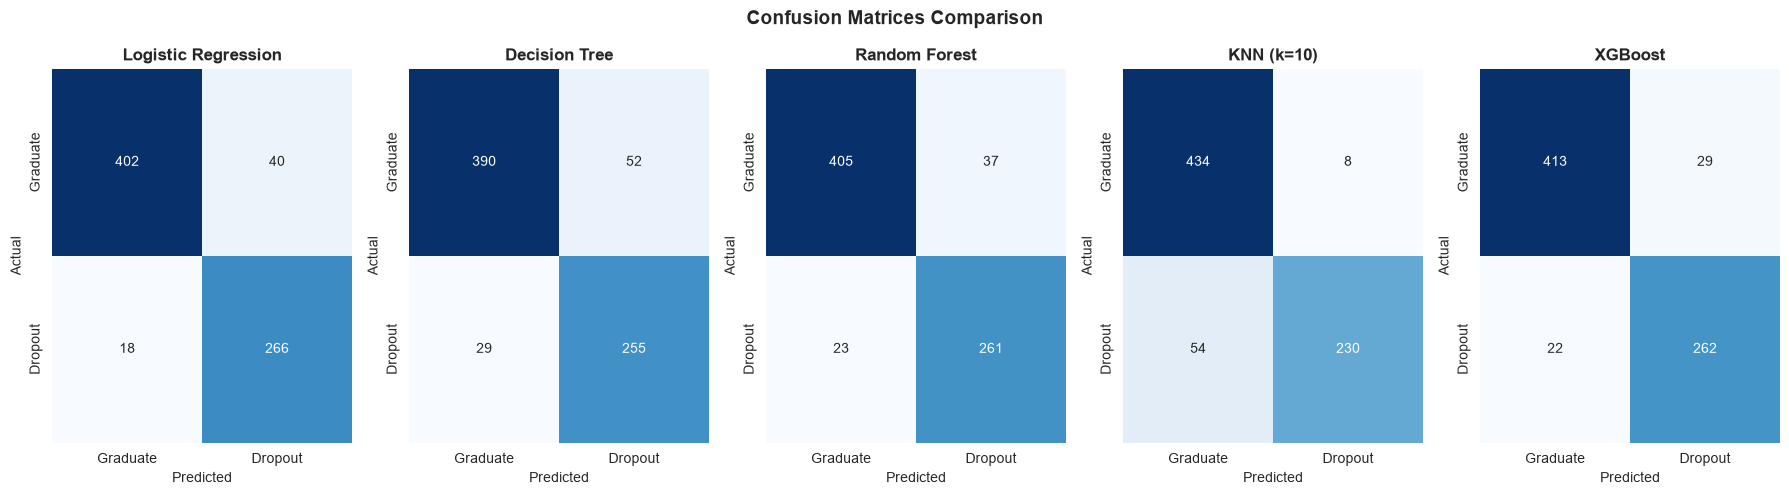

In [102]:
plot_confusion_matrices(all_results)

### 4.10.2 ROC Curves...

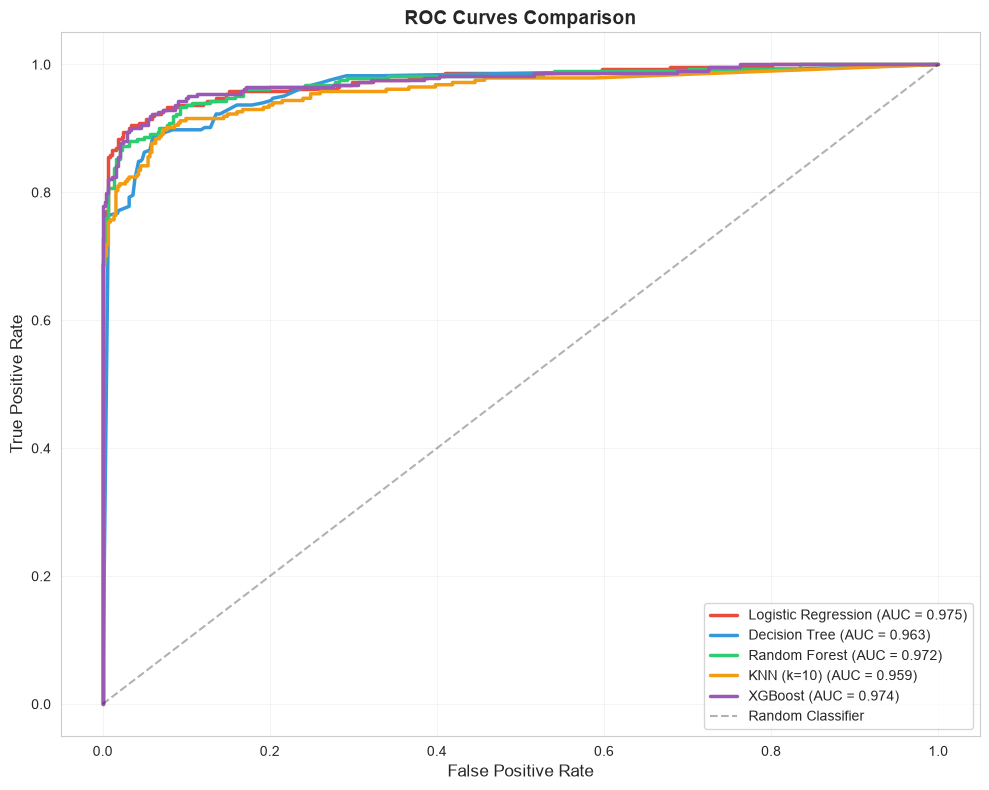

In [103]:
plot_roc_curves(all_results, y_test)

### 4.10.3 Metrics Comparison...

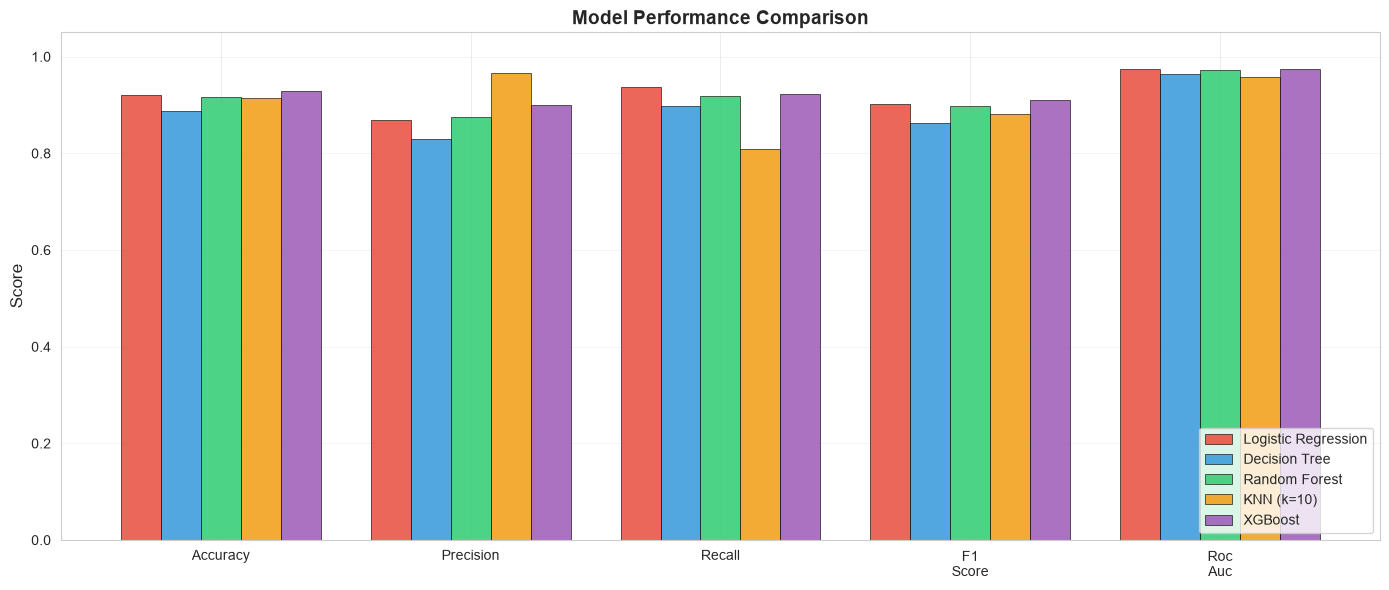

In [104]:
plot_metrics_comparison(all_results)

## 4.11 Learning Curves (Random Forest)

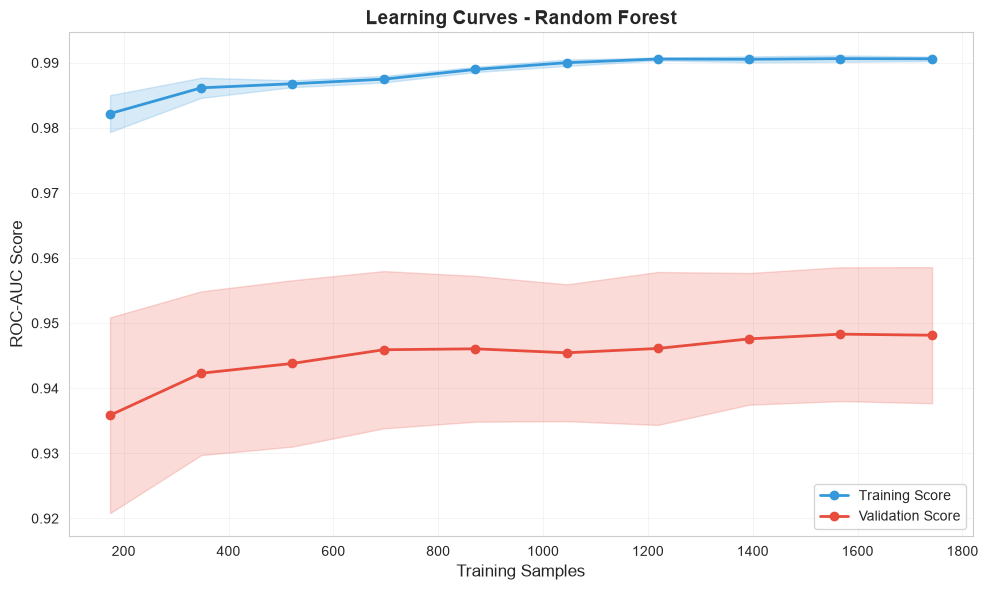

In [105]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10.0, 6.0))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#3498db')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#e74c3c')
ax.plot(train_sizes, train_mean, 'o-', color='#3498db', linewidth=2, label='Training Score')
ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', linewidth=2, label='Validation Score')
ax.set_xlabel('Training Samples', fontsize=12)
ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_title('Learning Curves - Random Forest', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.12 Probability Distribution Analysis

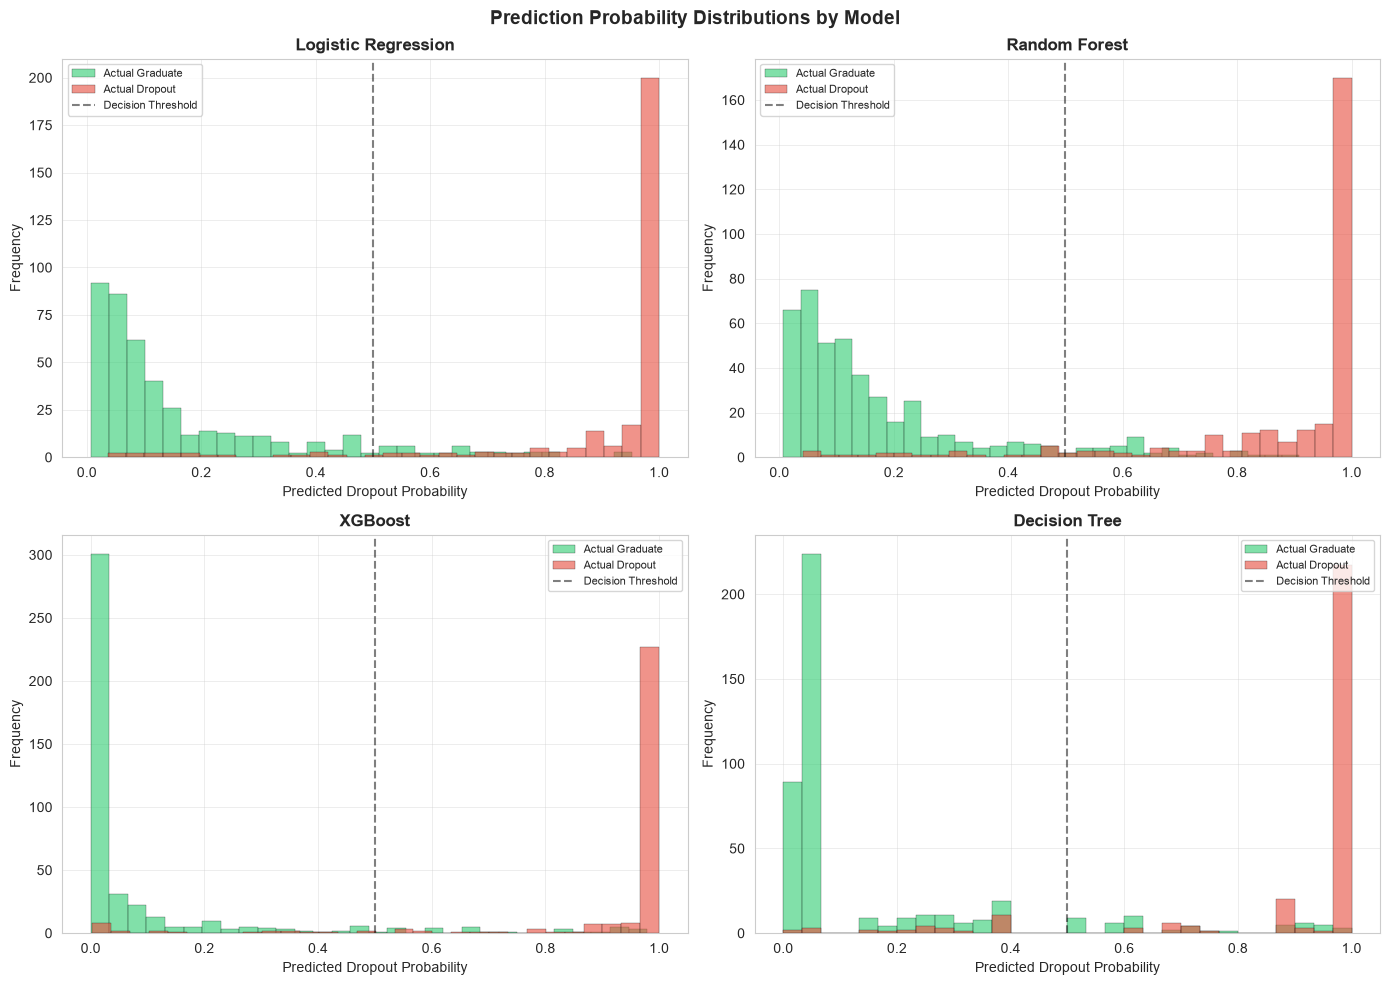

In [106]:
fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.0))
axes = axes.flatten()

models_to_plot = [lr_results, rf_results, xgb_results, dt_results]

for i, results in enumerate(models_to_plot[:4]):
    ax = axes[i]
    dropout_probs = results['y_proba'][y_test == 1]
    grad_probs = results['y_proba'][y_test == 0]
    ax.hist(grad_probs, bins=30, alpha=0.6, color='#2ecc71', label='Actual Graduate',
            edgecolor='black', linewidth=0.3)
    ax.hist(dropout_probs, bins=30, alpha=0.6, color='#e74c3c', label='Actual Dropout',
            edgecolor='black', linewidth=0.3)
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Decision Threshold')
    ax.set_xlabel('Predicted Dropout Probability')
    ax.set_ylabel('Frequency')
    ax.set_title(results['model_name'], fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Prediction Probability Distributions by Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/probability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.13 Save Models and Results

In [107]:
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

models_to_save = {
    'logistic_regression': lr_results['model'],
    'decision_tree': dt_results['model'],
    'random_forest': rf_results['model'],
    'knn': knn_results['model'],
    'xgboost': xgb_results['model'],
    'scaler': scaler
}

for name, model in models_to_save.items():
    filepath = models_dir / f'{name}.pkl'
    joblib.dump(model, filepath)
    print(f"    - {name}.pkl")

comparison_df.to_csv(models_dir / 'model_comparison.csv')
print(f"    - model_comparison.csv")

rf_importance.to_csv(models_dir / 'feature_importance_rf.csv', index=False)
print(f"    - feature_importance_rf.csv")

print()
print(f"All models saved to {models_dir}/")

    - logistic_regression.pkl
    - decision_tree.pkl
    - random_forest.pkl
    - knn.pkl
    - xgboost.pkl
    - scaler.pkl
    - model_comparison.csv
    - feature_importance_rf.csv

All models saved to ../models/


## 4.14 Summary

In [108]:
best_model_name = comparison_df['ROC-AUC'].idxmax()
best_roc_auc = comparison_df['ROC-AUC'].max()
best_f1 = comparison_df.loc[best_model_name, 'F1-Score']

print(f"""
═══════════════════════════════════════════════════════════════
BASELINE MODELING SUMMARY
═══════════════════════════════════════════════════════════════

PERFORMANCE OVERVIEW
    Total Models Trained:      5
    Best Model:                {best_model_name}
    Best ROC-AUC:              {best_roc_auc:.4f}
    Best F1-Score:             {best_f1:.4f}

MODEL RANKINGS (by ROC-AUC)""")

ranking = comparison_df.sort_values('ROC-AUC', ascending=False)
for i, (model, row) in enumerate(ranking.iterrows(), 1):
    print(f"    {i}. {model:<22s}  ROC-AUC: {row['ROC-AUC']:.4f}  F1: {row['F1-Score']:.4f}")

print(f"""
═══════════════════════════════════════════════════════════════
""")


═══════════════════════════════════════════════════════════════
BASELINE MODELING SUMMARY
═══════════════════════════════════════════════════════════════

PERFORMANCE OVERVIEW
    Total Models Trained:      5
    Best Model:                Logistic Regression
    Best ROC-AUC:              0.9749
    Best F1-Score:             0.9017

MODEL RANKINGS (by ROC-AUC)
    1. Logistic Regression     ROC-AUC: 0.9749  F1: 0.9017
    2. XGBoost                 ROC-AUC: 0.9743  F1: 0.9113
    3. Random Forest           ROC-AUC: 0.9723  F1: 0.8969
    4. Decision Tree           ROC-AUC: 0.9631  F1: 0.8629
    5. KNN (k=10)              ROC-AUC: 0.9588  F1: 0.8812

═══════════════════════════════════════════════════════════════



## Appendix: Quick Prediction Function

In [109]:
def predict_dropout_risk(student_data, model=None, scaler=None, feature_names=None):
    if model is None:
        model = rf_results['model']
    if feature_names is None:
        feature_names = X_train.columns.tolist()
    if isinstance(student_data, dict):
        student_df = pd.DataFrame([student_data])
    else:
        student_df = pd.DataFrame([student_data])
    student_df = student_df.reindex(columns=feature_names, fill_value=0)
    if scaler is not None:
        student_df = pd.DataFrame(scaler.transform(student_df), columns=feature_names)
    proba = model.predict_proba(student_df)[0, 1]
    prediction = model.predict(student_df)[0]
    return {
        'prediction': 'Dropout' if prediction == 1 else 'Graduate',
        'dropout_probability': proba,
        'risk_level': 'High' if proba > 0.7 else 'Medium' if proba > 0.4 else 'Low'
    }

print("Example prediction (first test sample):")
sample = X_test.iloc[0]
result = predict_dropout_risk(sample, model=rf_results['model'])
print(f"    Prediction: {result['prediction']}")
print(f"    Dropout Probability: {result['dropout_probability']:.1%}")
print(f"    Risk Level: {result['risk_level']}")
print(f"    Actual: {'Dropout' if y_test[0] == 1 else 'Graduate'}")

Example prediction (first test sample):
    Prediction: Graduate
    Dropout Probability: 11.9%
    Risk Level: Low
    Actual: Graduate
